
# CNN paso a paso: filtros (kernels), padding/stride, pooling y efecto en accuracy

Este notebook **no es interactivo**: va **paso a paso** mostrando conceptos clave de las CNN y cómo afectan al rendimiento.

Contenido:
1. Convolución 2D con kernels clásicos (blur, sharpen, Sobel) sobre imágenes reales.
2. Qué significan **kernel**, **stride**, **padding** y por qué cambian el tamaño del tensor.
3. **MaxPooling** vs **AvgPooling** y su efecto sobre feature maps.
4. Visualización de **filtros aprendidos** y **activaciones** (feature maps) de una CNN entrenada.
5. Mini-estudio: variar arquitectura (nº filtros, kernel size, pooling) y ver cómo cambia el **accuracy** final.


## 0) Setup

In [1]:

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

SEED = 42
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.optimizer.set_jit(True)
except Exception:
    pass


2026-02-20 13:34:37.864006: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-20 13:34:38.120928: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-20 13:34:38.120949: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-02-20 13:34:38.164179: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-20 13:34:38.929440: W tensorflow/stream_executor/platform/de

TensorFlow: 2.10.0
GPUs: []


2026-02-20 13:34:39.918538: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-02-20 13:34:39.919288: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-20 13:34:39.919502: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-02-20 13:34:39.919697: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-02-20 13:34:39.919769: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Co

## 1) Utilidades de visualización

In [2]:

def show_img(img, title=None, cmap=None):
    plt.figure(figsize=(3,3))
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[...,0]
    plt.imshow(img, cmap=cmap)
    plt.axis("off")
    if title: plt.title(title)
    plt.show()

def show_row(images, titles=None, cmap=None, figsize=(14,3)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, im in enumerate(images):
        plt.subplot(1, n, i+1)
        if im.ndim == 3 and im.shape[-1] == 1:
            im = im[...,0]
        plt.imshow(im, cmap=cmap)
        plt.axis("off")
        if titles is not None:
            plt.title(titles[i], fontsize=10)
    plt.tight_layout()
    plt.show()

def plot_history(history, title=None):
    if history is None:
        return
    h = history.history
    plt.figure(figsize=(6,4))
    if "loss" in h: plt.plot(h["loss"], label="train_loss")
    if "val_loss" in h: plt.plot(h["val_loss"], label="val_loss")
    plt.xlabel("epoch"); plt.ylabel("loss")
    if title: plt.title(title)
    plt.legend(); plt.show()

    if "accuracy" in h:
        plt.figure(figsize=(6,4))
        plt.plot(h["accuracy"], label="train_acc")
        if "val_accuracy" in h:
            plt.plot(h["val_accuracy"], label="val_acc")
        plt.xlabel("epoch"); plt.ylabel("accuracy")
        if title: plt.title(title)
        plt.legend(); plt.show()



## 2) Convolución 2D “a mano”: kernels clásicos

Aplicamos **kernels fijos** (no aprendidos) para entender qué hace la convolución.

- **Blur**: promedia vecinos.
- **Sharpen**: realce de bordes/contraste local.
- **Sobel**: detecta bordes horizontales/verticales.


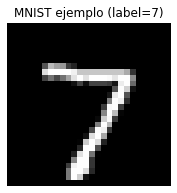

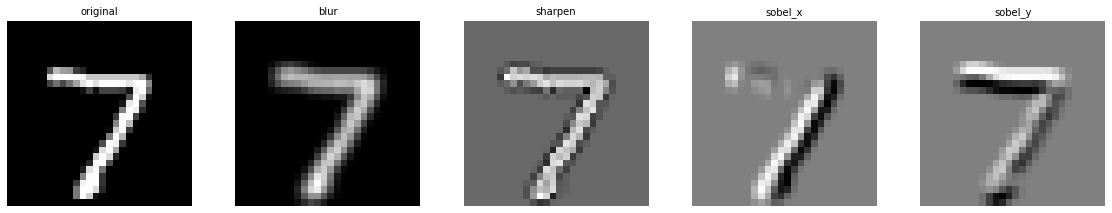

In [3]:

from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_test_f = x_test.astype("float32") / 255.0

idx = 0
img = x_test_f[idx]
label = y_test[idx]
show_img(img, title=f"MNIST ejemplo (label={label})", cmap="gray")

blur = np.array([[1,1,1],[1,1,1],[1,1,1]], dtype=np.float32) / 9.0
sharpen = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32)
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32)

kernels = {"blur": blur, "sharpen": sharpen, "sobel_x": sobel_x, "sobel_y": sobel_y}

def conv2d_same(image2d, kernel3x3):
    H, W = image2d.shape
    pad = 1
    padded = np.pad(image2d, ((pad,pad),(pad,pad)), mode="edge")
    out = np.zeros_like(image2d, dtype=np.float32)
    for i in range(H):
        for j in range(W):
            patch = padded[i:i+3, j:j+3]
            out[i,j] = np.sum(patch * kernel3x3)
    return out

outs, titles = [], []
for name, k in kernels.items():
    o = conv2d_same(img, k)
    o = o - o.min()
    if o.max() > 0: o = o / o.max()
    outs.append(o); titles.append(name)

show_row([img] + outs, ["original"] + titles, cmap="gray", figsize=(16,3))



## 3) Padding y Stride: cómo cambian los tamaños

- `padding="same"` mantiene tamaño (aprox.).
- `padding="valid"` no añade padding.
- `stride=2` reduce resolución (downsampling).


In [4]:

x = tf.zeros((1, 28, 28, 1))
for padding in ["valid", "same"]:
    for stride in [1, 2]:
        layer = layers.Conv2D(filters=8, kernel_size=3, strides=stride, padding=padding)
        y = layer(x)
        print(f"padding={padding:5s} stride={stride} -> output shape: {y.shape}")


padding=valid stride=1 -> output shape: (1, 26, 26, 8)
padding=valid stride=2 -> output shape: (1, 13, 13, 8)
padding=same  stride=1 -> output shape: (1, 28, 28, 8)
padding=same  stride=2 -> output shape: (1, 14, 14, 8)


2026-02-20 15:17:20.564092: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.



## 4) Pooling: MaxPooling vs AvgPooling

Pooling resume regiones (p.ej. 2×2) y reduce dimensión.
Visualizamos su efecto en un feature map de juguete.


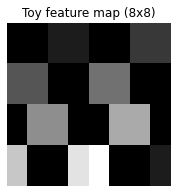

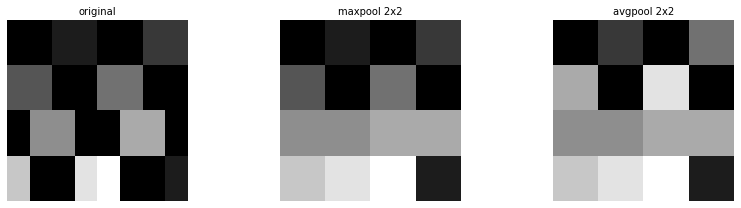

Shapes: (8, 8) -> (4, 4)


In [5]:

toy = np.array([
    [0,0,1,1, 0,0,2,2],
    [0,0,1,1, 0,0,2,2],
    [3,3,0,0, 4,4,0,0],
    [3,3,0,0, 4,4,0,0],
    [0,5,5,0, 0,6,6,0],
    [0,5,5,0, 0,6,6,0],
    [7,0,0,8, 9,0,0,1],
    [7,0,0,8, 9,0,0,1],
], dtype=np.float32)

show_img(toy, title="Toy feature map (8x8)", cmap="gray")
toy_tf = tf.constant(toy[None,...,None])

maxp = layers.MaxPooling2D(pool_size=2)(toy_tf).numpy()[0,...,0]
avgp = layers.AveragePooling2D(pool_size=2)(toy_tf).numpy()[0,...,0]

show_row([toy, maxp, avgp], ["original", "maxpool 2x2", "avgpool 2x2"], cmap="gray", figsize=(12,3))
print("Shapes:", toy.shape, "->", maxp.shape)



## 5) Entrenamos una CNN pequeña (MNIST) para visualizar filtros y activaciones

Entrenamos rápido (pocas épocas) para ver:
- **filtros aprendidos** en la primera conv.
- **feature maps** antes y después del pooling.


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv1 (Conv2D)              (None, 28, 28, 16)        160       
                                                                 
 pool1 (MaxPooling2D)        (None, 14, 14, 16)        0         
                                                                 
 conv2 (Conv2D)              (None, 14, 14, 32)        4640      
                                                                 
 pool2 (MaxPooling2D)        (None, 7, 7, 32)          0         
                                                                 
 flatten (Flatten)           (None, 1568)              0         
                                                                 
 dense (Dense)               (None, 64)                100416

2026-02-20 15:22:49.415202: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 62720000 exceeds 10% of free system memory.
2026-02-20 15:22:49.592460: W tensorflow/compiler/jit/mark_for_compilation_pass.cc:1780] (One-time warning): Not using XLA:CPU for cluster.

If you want XLA:CPU, do one of the following:

 - set the TF_XLA_FLAGS to include "--tf_xla_cpu_global_jit", or
 - set cpu_global_jit to true on this session's OptimizerOptions, or
 - use experimental_jit_scope, or
 - use tf.function(jit_compile=True).

To confirm that XLA is active, pass --vmodule=xla_compilation_cache=1 (as a
proper command-line flag, not via TF_XLA_FLAGS).


157/157 [==============================] - 3s 16ms/step - loss: 0.5914 - accuracy: 0.8414 - val_loss: 0.2163 - val_accuracy: 0.9388
Epoch 2/3
157/157 [==============================] - 2s 14ms/step - loss: 0.1574 - accuracy: 0.9541 - val_loss: 0.1400 - val_accuracy: 0.9572
Epoch 3/3
157/157 [==============================] - 2s 14ms/step - loss: 0.1031 - accuracy: 0.9700 - val_loss: 0.1027 - val_accuracy: 0.9702
Test accuracy: 0.9737


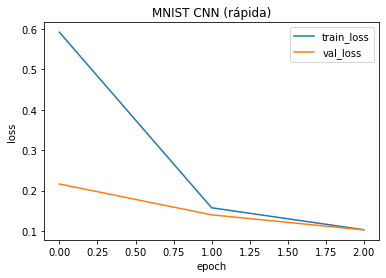

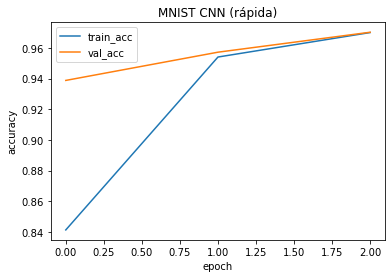

In [6]:

x_train_n = (x_train.astype("float32")/255.0)[...,None]
x_test_n  = (x_test.astype("float32")/255.0)[...,None]

val_size = 10000
x_val, y_val = x_train_n[-val_size:], y_train[-val_size:]
x_tr , y_tr  = x_train_n[:-val_size], y_train[:-val_size]

# Subsets para rapidez
x_tr_s, y_tr_s = x_tr[:20000], y_tr[:20000]
x_val_s, y_val_s = x_val[:5000], y_val[:5000]

def build_mnist_cnn(filters=16, kernel=3, use_pool=True):
    inp = keras.Input(shape=(28,28,1))
    x = layers.Conv2D(filters, kernel, padding="same", activation="relu", name="conv1")(inp)
    if use_pool:
        x = layers.MaxPooling2D(name="pool1")(x)
    x = layers.Conv2D(filters*2, kernel, padding="same", activation="relu", name="conv2")(x)
    if use_pool:
        x = layers.MaxPooling2D(name="pool2")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(10, activation="softmax")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

model = build_mnist_cnn(filters=16, kernel=3, use_pool=True)
model.summary()

history = model.fit(
    x_tr_s, y_tr_s,
    validation_data=(x_val_s, y_val_s),
    epochs=3,
    batch_size=128,
    verbose=1
)

te_loss, te_acc = model.evaluate(x_test_n, y_test, verbose=0)
print("Test accuracy:", round(float(te_acc), 4))
plot_history(history, title="MNIST CNN (rápida)")



## 6) Visualizar filtros aprendidos (conv1)

`conv1` tiene pesos con forma `(k, k, in_channels, out_channels)`.
Como MNIST tiene 1 canal, podemos pintar cada filtro como una imagen 2D.


W shape: (3, 3, 1, 16) | b shape: (16,)


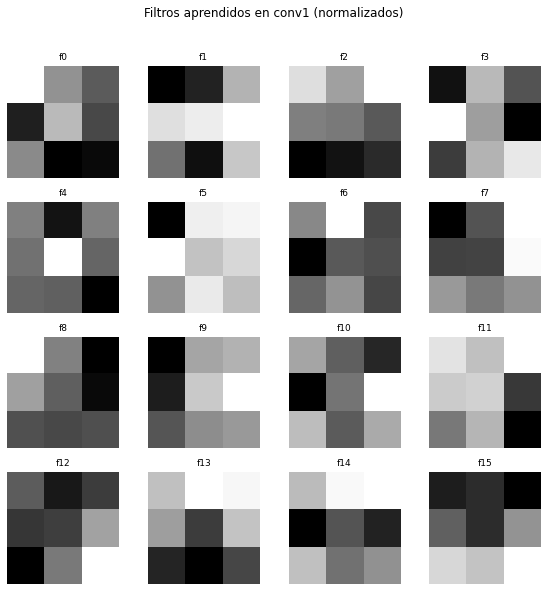

In [7]:

conv1 = model.get_layer("conv1")
W, b = conv1.get_weights()
print("W shape:", W.shape, "| b shape:", b.shape)

k = W.shape[0]
n_filters = W.shape[-1]

filters = []
for i in range(n_filters):
    f = W[...,0,i]
    f = f - f.min()
    if f.max() > 0: f = f / f.max()
    filters.append(f)

cols = int(math.ceil(math.sqrt(n_filters)))
rows = int(math.ceil(n_filters / cols))
plt.figure(figsize=(2*cols, 2*rows))
for i, f in enumerate(filters):
    plt.subplot(rows, cols, i+1)
    plt.imshow(f, cmap="gray")
    plt.axis("off")
    plt.title(f"f{i}", fontsize=9)
plt.suptitle("Filtros aprendidos en conv1 (normalizados)", y=1.02)
plt.tight_layout()
plt.show()



## 7) Activaciones (feature maps) y efecto del pooling

Construimos un modelo que devuelva:
- salida de `conv1`
- salida de `pool1`
y las comparamos para una misma imagen.


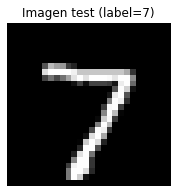

conv1: (1, 28, 28, 16) pool1: (1, 14, 14, 16)


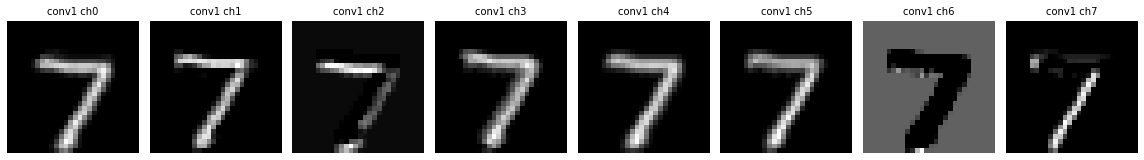

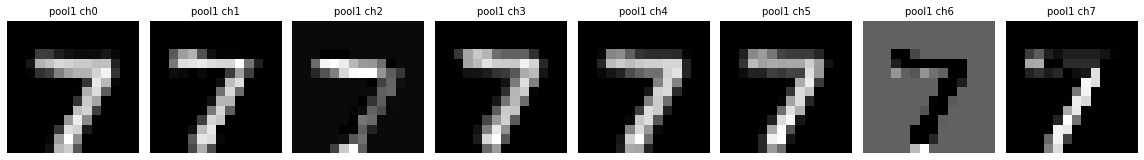

In [8]:

inspector = keras.Model(
    inputs=model.input,
    outputs=[model.get_layer("conv1").output, model.get_layer("pool1").output]
)

i = 0
x0 = x_test_n[i:i+1]
y0 = y_test[i]
show_img(x0[0], title=f"Imagen test (label={y0})", cmap="gray")

act_conv1, act_pool1 = inspector.predict(x0, verbose=0)
print("conv1:", act_conv1.shape, "pool1:", act_pool1.shape)

def norm01(a):
    a = a - a.min()
    return a / a.max() if a.max() > 0 else a

n_show = 8
conv_maps = [norm01(act_conv1[0,:,:,c]) for c in range(n_show)]
pool_maps = [norm01(act_pool1[0,:,:,c]) for c in range(n_show)]

show_row(conv_maps, [f"conv1 ch{c}" for c in range(n_show)], cmap="gray", figsize=(16,3))
show_row(pool_maps, [f"pool1 ch{c}" for c in range(n_show)], cmap="gray", figsize=(16,3))



## 8) Mini-estudio: variar arquitectura y ver impacto en accuracy

Comparamos variantes rápidas (pocas épocas + subset):
- con/sin pooling
- nº filtros
- kernel 3 vs 5


In [9]:

# Dataset reducido para comparar rápido
train_n = 15000
val_n = 5000
xtr, ytr = x_tr[:train_n], y_tr[:train_n]
xva, yva = x_val[:val_n], y_val[:val_n]

def train_eval_config(filters, kernel, use_pool, epochs=3):
    m = build_mnist_cnn(filters=filters, kernel=kernel, use_pool=use_pool)
    h = m.fit(xtr, ytr, validation_data=(xva, yva),
              epochs=epochs, batch_size=128, verbose=0)
    te_loss, te_acc = m.evaluate(x_test_n, y_test, verbose=0)
    va_acc = float(max(h.history.get("val_accuracy",[np.nan])))
    return float(te_acc), va_acc, int(m.count_params())

configs = [
    {"filters": 8,  "kernel": 3, "use_pool": True},
    {"filters": 16, "kernel": 3, "use_pool": True},
    {"filters": 32, "kernel": 3, "use_pool": True},
    {"filters": 16, "kernel": 5, "use_pool": True},
    {"filters": 16, "kernel": 3, "use_pool": False},
]

rows = []
for cfg in configs:
    te_acc, va_acc, params = train_eval_config(**cfg, epochs=3)
    rows.append({**cfg, "val_acc_best": va_acc, "test_acc": te_acc, "params": params})
    print(cfg, "-> test_acc:", round(te_acc,4), "val_best:", round(va_acc,4), "params:", params)

df = pd.DataFrame(rows).sort_values("test_acc", ascending=False)
df


{'filters': 8, 'kernel': 3, 'use_pool': True} -> test_acc: 0.9592 val_best: 0.9546 params: 52138
{'filters': 16, 'kernel': 3, 'use_pool': True} -> test_acc: 0.9718 val_best: 0.9668 params: 105866
{'filters': 32, 'kernel': 3, 'use_pool': True} -> test_acc: 0.9775 val_best: 0.9726 params: 220234
{'filters': 16, 'kernel': 5, 'use_pool': True} -> test_acc: 0.9724 val_best: 0.972 params: 114314
{'filters': 16, 'kernel': 3, 'use_pool': False} -> test_acc: 0.9699 val_best: 0.972 params: 1611146


,filters,kernel,use_pool,val_acc_best,test_acc,params
2,32,3,True,0.9726,0.9775,220234
3,16,5,True,0.9720,0.9724,114314
1,16,3,True,0.9668,0.9718,105866
4,16,3,False,0.9720,0.9699,1611146
0,8,3,True,0.9546,0.9592,52138



### 8.1) Gráfica rápida de comparación


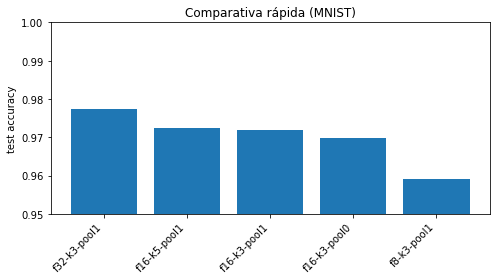

,filters,kernel,use_pool,val_acc_best,test_acc,params
0,32,3,True,0.9726,0.9775,220234
1,16,5,True,0.9720,0.9724,114314
2,16,3,True,0.9668,0.9718,105866
3,16,3,False,0.9720,0.9699,1611146
4,8,3,True,0.9546,0.9592,52138


In [11]:

plt.figure(figsize=(7,4))
plt.bar(range(len(df)), df["test_acc"])
plt.xticks(
    range(len(df)),
    [f'f{r.filters}-k{r.kernel}-pool{int(r.use_pool)}' for r in df.itertuples()],
    rotation=45, ha="right"
)
plt.ylabel("test accuracy")
plt.ylim([0.95,1])
plt.title("Comparativa rápida (MNIST)")
plt.tight_layout()
plt.show()

display(df.reset_index(drop=True))



## 9) Extensión corta a CIFAR-10 (opcional)

CIFAR-10 es más difícil (color, más variación). Baseline rápido para ver que el problema cambia.


2026-02-20 15:30:19.753480: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 245760000 exceeds 10% of free system memory.


Epoch 1/5
157/157 [==============================] - 8s 50ms/step - loss: 2.0508 - accuracy: 0.2224 - val_loss: 1.8982 - val_accuracy: 0.2678
Epoch 2/5
157/157 [==============================] - 7s 47ms/step - loss: 1.8067 - accuracy: 0.3149 - val_loss: 1.7002 - val_accuracy: 0.3444
Epoch 3/5
157/157 [==============================] - 7s 47ms/step - loss: 1.6753 - accuracy: 0.3758 - val_loss: 1.6049 - val_accuracy: 0.3978
Epoch 4/5
157/157 [==============================] - 7s 46ms/step - loss: 1.5932 - accuracy: 0.4072 - val_loss: 1.5552 - val_accuracy: 0.4136
Epoch 5/5
157/157 [==============================] - 7s 47ms/step - loss: 1.5372 - accuracy: 0.4331 - val_loss: 1.5346 - val_accuracy: 0.4306


2026-02-20 15:30:58.193637: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


CIFAR-10 test acc (rápido): 0.4362


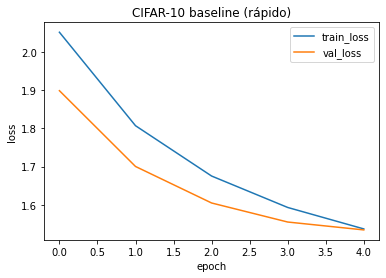

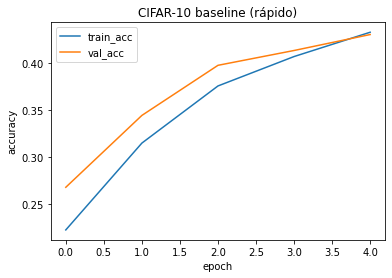

In [12]:

from tensorflow.keras.datasets import cifar10

(xc_tr, yc_tr), (xc_te, yc_te) = cifar10.load_data()
yc_tr = yc_tr.squeeze(); yc_te = yc_te.squeeze()
xc_tr = xc_tr.astype("float32")/255.0
xc_te = xc_te.astype("float32")/255.0

val_size = 5000
xc_val, yc_val = xc_tr[-val_size:], yc_tr[-val_size:]
xc_tr2, yc_tr2 = xc_tr[:-val_size], yc_tr[:-val_size]

# subset para rapidez
xc_tr2 = xc_tr2[:20000]; yc_tr2 = yc_tr2[:20000]
xc_val = xc_val[:5000];  yc_val = yc_val[:5000]

def build_cifar_small():
    inp = keras.Input(shape=(32,32,3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(10, activation="softmax")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

m = build_cifar_small()
h = m.fit(xc_tr2, yc_tr2, validation_data=(xc_val, yc_val),
          epochs=5, batch_size=128, verbose=1)

te_loss, te_acc = m.evaluate(xc_te, yc_te, verbose=0)
print("CIFAR-10 test acc (rápido):", round(float(te_acc),4))
plot_history(h, title="CIFAR-10 baseline (rápido)")



# Takeaways

- La convolución aplica **filtros locales**; kernels distintos detectan patrones distintos.
- `padding` y `stride` cambian el tamaño de la salida (y el coste).
- **Pooling** reduce dimensión y puede mejorar generalización, pero pierde detalle.
- Más filtros / kernels mayores suelen aumentar capacidad (y coste) y pueden subir accuracy.
